Epoch 0, Loss 36.43
Epoch 50, Loss 0.07
Epoch 100, Loss 0.02
Epoch 150, Loss 0.01
Output: ['je', 'suis', 'content']


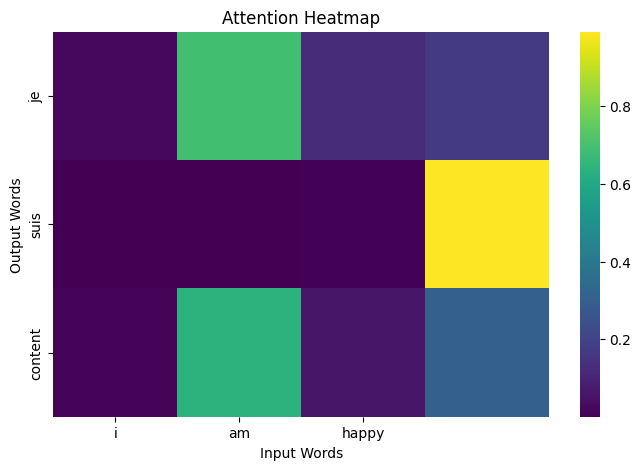

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔹 Dataset
pairs = [
    ("i am happy", "je suis content"),
    ("he is good", "il est bon"),
    ("she is sad", "elle est triste"),
    ("i am learning", "je apprends"),
]

# 🔹 Vocabulary
def build_vocab(sentences):
    vocab = {"<pad>":0, "<sos>":1, "<eos>":2}
    idx = 3
    for sent in sentences:
        for word in sent.split():
            if word not in vocab:
                vocab[word] = idx
                idx += 1
    return vocab

input_vocab = build_vocab([p[0] for p in pairs])
output_vocab = build_vocab([p[1] for p in pairs])
inv_output_vocab = {v:k for k,v in output_vocab.items()}

def encode(sentence, vocab):
    return [vocab[w] for w in sentence.split()] + [vocab["<eos>"]]

# 🔹 Encoder
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size)

    def forward(self, x):
        x = x.unsqueeze(1)  # [seq_len,1]
        embedded = self.embed(x)  # [seq_len,1,embed]
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

# 🔹 Attention
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v = nn.Linear(hidden_size, 1)

    def forward(self, hidden, encoder_outputs):
        seq_len = encoder_outputs.shape[0]

        hidden = hidden.repeat(seq_len, 1, 1)
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)

        return torch.softmax(attention, dim=0)

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.attention = Attention(hidden_size)

    def forward(self, x, hidden, encoder_outputs):
        # x shape: [1] → make [1,1]
        x = x.view(1, 1)   # 🔥 safest reshape

        embedded = self.embed(x)  # [1,1,embed]

        attn_weights = self.attention(hidden, encoder_outputs)  # [seq_len,1]

        # context: [1, hidden]
        context = torch.sum(attn_weights.unsqueeze(2) * encoder_outputs, dim=0)

        # reshape to [1,1,hidden]
        context = context.view(1, 1, -1)

        # concat → [1,1,embed+hidden]
        rnn_input = torch.cat((embedded, context), dim=2)

        output, hidden = self.rnn(rnn_input, hidden)

        prediction = self.fc(output.squeeze(0))  # [1,vocab]

        return prediction, hidden, attn_weights

# 🔹 Init
embed_size = 16
hidden_size = 32

encoder = Encoder(len(input_vocab), embed_size, hidden_size).to(device)
decoder = Decoder(len(output_vocab), embed_size, hidden_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.01)

# 🔹 Training
for epoch in range(200):
    total_loss = 0
    for src, trg in pairs:
        src_tensor = torch.tensor(encode(src, input_vocab), dtype=torch.long).to(device)
        trg_tensor = torch.tensor([output_vocab["<sos>"]] + encode(trg, output_vocab), dtype=torch.long).to(device)

        encoder_outputs, hidden = encoder(src_tensor)

        loss = 0
        input_token = trg_tensor[0]

        for t in range(1, len(trg_tensor)):
            output, hidden, _ = decoder(input_token, hidden, encoder_outputs)
            loss += criterion(output, trg_tensor[t].unsqueeze(0))
            input_token = trg_tensor[t]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss {total_loss:.2f}")

# 🔹 Translation + Attention
def translate(sentence):
    src_tensor = torch.tensor(encode(sentence, input_vocab), dtype=torch.long).to(device)
    encoder_outputs, hidden = encoder(src_tensor)

    input_token = torch.tensor([output_vocab["<sos>"]]).to(device)

    outputs = []
    attentions = []

    for _ in range(10):
        output, hidden, attn = decoder(input_token, hidden, encoder_outputs)
        top1 = output.argmax(1)

        if top1.item() == output_vocab["<eos>"]:
            break

        outputs.append(inv_output_vocab[top1.item()])
        attentions.append(attn.squeeze(1).cpu().detach().numpy())
        input_token = top1

    return outputs, attentions, sentence.split()

# 🔹 Run Example
output_words, attentions, input_words = translate("i am happy")
print("Output:", output_words)

# 🔴 Heatmap
attn_matrix = np.array(attentions)

plt.figure(figsize=(8,5))
sns.heatmap(attn_matrix, xticklabels=input_words, yticklabels=output_words, cmap="viridis")
plt.xlabel("Input Words")
plt.ylabel("Output Words")
plt.title("Attention Heatmap")
plt.show()